## Figure 2 from formation channel paper 

below is the code that reproduces Figure 2 of the formation channel paper 


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 

In [2]:
## data path
path_to_github_folder = "/Users/floorbroekgaarden/Projects/GitHub/"
path_to_file_folder = "Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/"
path_to_file = path_to_github_folder + path_to_file_folder


### Instructions 

for this code to work you will need the following files 
  - `DCOlabel + "_rates_review.csv"` For DCOlabel in BH-BH, BH-NS, and NS-NS  
 you can find this in the Zenodo file or on GitHub inside the Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/ folder 
  - it imports some functions from the `common_code` file above, but you dont need this :) (just uncomment if needed) 
  - likely you want to change the `save_path` in the code call below 
  

In [3]:
def plot_withoutCE_three_DCOs(
    path_to_file,
    sort_header="fraction without common envelope",
    save_path="formation_channels_withoutCE_summary.pdf",
    add_jitter=True,
    jitter_scale=0.05,
    point_size=40,
    alpha=0.8,
):
    """
    Plot all simulations for:
      - BBH (BH-BH) in black
      - BHNS in blue
      - BNS (NS-NS) in gold

    on three horizontal lines as a function of the chosen fraction.

    Expected files in path_to_file:
      - BH-BH_rates_review.csv
      - BH-NS_rates_review.csv
      - NS-NS_rates_review.csv
    """

    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # ----------------------------
    # helper: load one DCO file
    # ----------------------------
    def _load_one(path_to_file, DCOlabel):
        file_name = DCOlabel + "_rates_review.csv"
        csv_path = os.path.join(path_to_file, file_name)

        df = pd.read_csv(csv_path)

        if sort_header not in df.columns:
            raise ValueError(
                f"Column '{sort_header}' not found in {csv_path}.\n"
                f"Available columns are:\n{list(df.columns)}"
            )

        df = df.copy()
        df["DCOlabel"] = DCOlabel
        df[sort_header] = pd.to_numeric(df[sort_header], errors="coerce")
        df = df.dropna(subset=[sort_header])

        # keep only physical fractions
        df = df[(df[sort_header] >= 0) & (df[sort_header] <= 1)]

        return df

    # ----------------------------
    # load all three populations
    # ----------------------------
    df_bbh  = _load_one(path_to_file, "BH-BH")
    df_bhns = _load_one(path_to_file, "BH-NS")
    df_bns  = _load_one(path_to_file, "NS-NS")

    df_all = pd.concat([df_bbh, df_bhns, df_bns], ignore_index=True)

    # ----------------------------
    # plotting setup
    # ----------------------------
    y_map = {
        "BH-BH": 2.0,
        "BH-NS": 1.0,
        "NS-NS": 0.0,
    }

    color_map = {
        "BH-BH": "black",
        "BH-NS": "tab:blue",
        "NS-NS": "gold",
    }

    label_map = {
        "BH-BH": "BBH",
        "BH-NS": "BHNS",
        "NS-NS": "BNS",
    }

    rng = np.random.default_rng(42)

    fig, ax = plt.subplots(figsize=(10, 3.2))

    # horizontal guide lines
    for dco in ["NS-NS", "BH-NS", "BH-BH"]:
        ax.hlines(
            y=y_map[dco],
            xmin=0,
            xmax=1,
            linewidth=1.0,
            alpha=0.35,
            color="gray",
            zorder=0,
        )

    # light background bands
    for dco, y in y_map.items():
        ax.axhspan(y - 0.25, y + 0.25, color="gray", alpha=0.05, zorder=0)

    # scatter each class
    for dco in ["BH-BH", "BH-NS", "NS-NS"]:
        sub = df_all[df_all["DCOlabel"] == dco].copy()
        x = sub[sort_header].to_numpy()
        y = np.full(len(sub), y_map[dco], dtype=float)

        if add_jitter:
            y += rng.uniform(-jitter_scale, jitter_scale, size=len(sub))

        ax.scatter(
            x,
            y,
            s=point_size,
            color=color_map[dco],
            alpha=alpha,
            edgecolors="black",
            linewidths=0.6,
            zorder=3,
            label=label_map[dco],
        )

    # counts on right
    counts = df_all["DCOlabel"].value_counts()
    for dco in ["NS-NS", "BH-NS", "BH-BH"]:
        ax.text(
            1.02,
            y_map[dco],
            f"{counts.get(dco, 0)} data points",
            va="center",
            fontsize=12,
        )

    # ----------------------------
    # cosmetics: bottom axis
    # ----------------------------
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.4, 2.4)

    xticks = np.arange(0, 1.01, 0.1)
    ax.set_xticks(xticks)
    ax.set_xticks(np.arange(0, 1.01, 0.05), minor=True)

    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.25)

    ax.set_yticks([0.0, 1.0, 2.0])
    ax.set_yticklabels(["BNS", "BHNS", "BBH"])

    if sort_header == "fraction with common envelope":
        bottom_label = r"$\textbf{Fraction forming with CE}$"
        top_label    = r"$\textbf{Fraction forming without CE}$"
    else:
        bottom_label = r"$\textbf{Fraction forming without CE}$"
        top_label    = r"$\textbf{Fraction forming with CE}$"

    ax.set_xlabel(bottom_label, fontsize=20)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.5)

    ax.tick_params(axis='x', which='minor', length=4, width=1)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=16,
        length=6,
        width=1.5
    )

    # ----------------------------
    # mirrored top axis: x_top = 1 - x_bottom
    # ----------------------------
    secax = ax.secondary_xaxis(
        "top",
        functions=(lambda x: 1 - x, lambda x: 1 - x)
    )

    # labels
    secax.set_xlabel(
        top_label,
        fontsize=12,
        fontweight="normal",
        color="0.35"
    )

    # let matplotlib place mirrored ticks correctly
    secax.set_xticks(np.arange(0, 1.01, 0.1))

    # subtle top spine + ticks
    secax.spines["top"].set_linewidth(0.6)
    secax.spines["top"].set_color("0.5")

    secax.tick_params(
        axis="x",
        which="major",
        labelsize=11,
        length=4,
        width=0.6,
        colors="0.5"
    )
    secax.spines["top"].set_linewidth(1)
    secax.spines["top"].set_color("0.6")

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    print(f"Saved to: {save_path}")

    return fig, ax, df_all

Saved to: Output_Figures/Fig2_formation_channels_witCE_three_lines.pdf


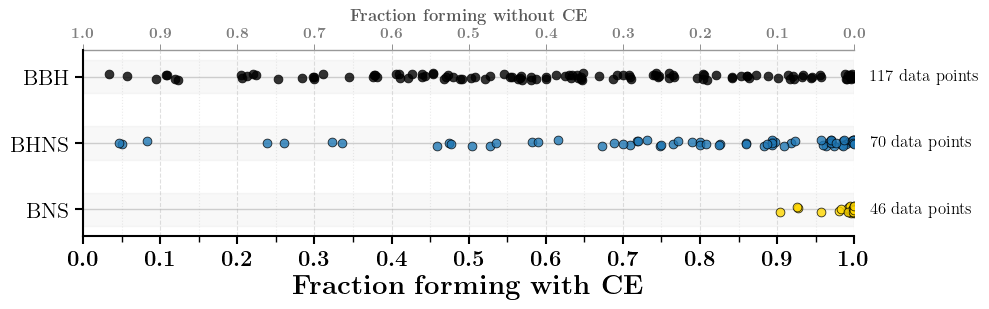

In [4]:


fig, ax, df_all = plot_withoutCE_three_DCOs(
    path_to_file=path_to_file,
    sort_header="fraction with common envelope",
    save_path="Output_Figures/Fig2_formation_channels_witCE_three_lines.pdf",
)


plt.show()
# display(fig)



Saved to: Output_Figures/Fig2_formation_channels_withoutCE_three_lines.pdf


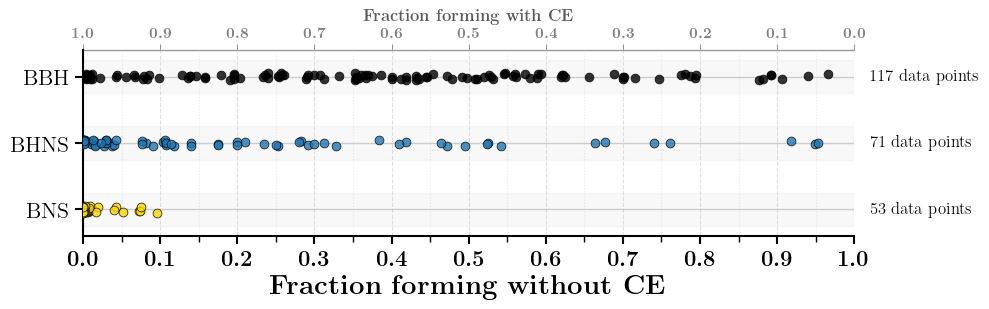

In [5]:

fig, ax, df_all = plot_withoutCE_three_DCOs(
    path_to_file=path_to_file,
    sort_header="fraction without common envelope",
    save_path="Output_Figures/Fig2_formation_channels_withoutCE_three_lines.pdf",
)

plt.show()




### some old code (just to make variations of the above plot)

In [6]:
# ## some old code that doesnt have the second axis 



# def plot_withoutCE_three_DCOs(
#     path_to_file,
#     sort_header="fraction without common envelope",
#     save_path="formation_channels_withoutCE_summary.pdf",
#     add_jitter=True,
#     jitter_scale=0.05,
#     point_size=26,
#     alpha=0.8,
# ):
#     """
#     Plot all simulations for:
#       - BBH (BH-BH) in black
#       - BHNS in blue
#       - BNS (NS-NS) in gold

#     on three horizontal lines as a function of the
#     'fraction without common envelope'.

#     Expected files in path_to_file:
#       - BH-BH_rates_review.csv
#       - BH-NS_rates_review.csv
#       - NS-NS_rates_review.csv
#     """

#     # ----------------------------
#     # helper: load one DCO file
#     # ----------------------------
#     def _load_one(path_to_file, DCOlabel):
#         file_name = DCOlabel + "_rates_review.csv"
#         csv_path = os.path.join(path_to_file, file_name)

#         df = pd.read_csv(csv_path)

#         if sort_header not in df.columns:
#             raise ValueError(
#                 f"Column '{sort_header}' not found in {csv_path}.\n"
#                 f"Available columns are:\n{list(df.columns)}"
#             )

#         df = df.copy()
#         df["DCOlabel"] = DCOlabel
#         df[sort_header] = pd.to_numeric(df[sort_header], errors="coerce")
#         df = df.dropna(subset=[sort_header])

#         # keep only physical fractions
#         df = df[(df[sort_header] >= 0) & (df[sort_header] <= 1)]

#         return df

#     # ----------------------------
#     # load all three populations
#     # ----------------------------
#     df_bbh  = _load_one(path_to_file, "BH-BH")
#     df_bhns = _load_one(path_to_file, "BH-NS")
#     df_bns  = _load_one(path_to_file, "NS-NS")

#     df_all = pd.concat([df_bbh, df_bhns, df_bns], ignore_index=True)

#     # ----------------------------
#     # plotting setup
#     # ----------------------------
#     y_map = {
#         "BH-BH": 2.0,
#         "BH-NS": 1.0,
#         "NS-NS": 0.0,
#     }

#     color_map = {
#         "BH-BH": "black",
#         "BH-NS": "tab:blue",
#         "NS-NS": "gold",
#     }

#     label_map = {
#         "BH-BH": "BBH",
#         "BH-NS": "BHNS",
#         "NS-NS": "BNS",
#     }

#     rng = np.random.default_rng(42)

#     fig, ax = plt.subplots(figsize=(10, 3.2))

#     # horizontal guide lines
#     for dco in ["NS-NS", "BH-NS", "BH-BH"]:
#         ax.hlines(
#             y=y_map[dco],
#             xmin=0,
#             xmax=1,
#             linewidth=1.0,
#             alpha=0.35,
#             color="gray",
#             zorder=0,
#         )

#     # scatter each class
#     for dco in ["BH-BH", "BH-NS", "NS-NS"]:
#         sub = df_all[df_all["DCOlabel"] == dco].copy()
#         x = sub[sort_header].to_numpy()
#         y = np.full(len(sub), y_map[dco], dtype=float)

#         if add_jitter:
#             y += rng.uniform(-jitter_scale, jitter_scale, size=len(sub))

#         ax.scatter(
#             x,
#             y,
#             s=40,                      # increase size so edge is visible
#             color=color_map[dco],
#             alpha=alpha,
#             edgecolors="black",        # <-- black edge
#             linewidths=0.6,            # <-- edge thickness
#             zorder=3,
#             label=label_map[dco],
#         )

        
        
#     for dco, y in y_map.items():
#         ax.axhspan(y - 0.25, y + 0.25, color="gray", alpha=0.05, zorder=0)
#     # ----------------------------
#     # cosmetics
#     # ----------------------------
#     counts = df_all["DCOlabel"].value_counts()

#     for dco in ["NS-NS", "BH-NS", "BH-BH"]:
#         ax.text(
#             1.02,                              # just outside the axis
#             y_map[dco],
#             f"{counts.get(dco, 0)} data points",
#             va="center",
#             fontsize=12,
#         )
        
#     ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
#     ax.grid(axis="x", which="minor", linestyle=":", alpha=0.25)
    
#     ax.set_xlim(0, 1)
#     ax.set_ylim(-0.4, 2.4)
#     if sort_header=="fraction with common envelope":
#         ax.set_xlabel(r"$\textbf{Fraction forming with common envelope}$", fontsize=20)
#     else: 
#         ax.set_xlabel(r"$\textbf{Fraction forming without common envelope}$", fontsize=20)
# #     ax.set_xlabel("Fraction forming without common envelope", fontsize=18)
#     ax.set_yticks([0.0, 1.0, 2.0])
#     ax.set_yticklabels(["BNS", "BHNS", "BBH"])

#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)

#     # set ticks every 0.1 WITH labels
#     xticks = np.arange(0, 1.01, 0.1)
#     ax.set_xticks(xticks)
#     ax.tick_params(axis='x', which='minor', length=4, width=1)
    
#     for spine in ["left", "bottom"]:
#         ax.spines[spine].set_linewidth(1.5)
    
#     ax.tick_params(
#         axis='both',
#         which='major',
#         labelsize=16,   # tick label fontsize
#         length=6,       # tick length
#         width=1.5       # tick thickness
#     )
    

#     fig.tight_layout()
#     fig.savefig(save_path, bbox_inches="tight", dpi=300)
#     print(f"Saved to: {save_path}")

#     return fig, ax, df_all



# fig, ax, df_all = plot_withoutCE_three_DCOs(
#     path_to_file=path_to_file,
#     sort_header="fraction without common envelope",
#     save_path="Output_Figures/Fig2_formation_channels_withoutCE_three_lines.pdf",
# )

# plt.show()





